# Анализ результатов A/B-тестирования интернет-магазина BitMotion Kit

В интернет-магазине BitMotion Kit продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. Необходимо провести оценку результатов A/B-теста и проанализировать его результаты.

**Цель исследования**: оценить, увеличивает ли новый интерфейс конверсию в покупку

**Гипотеза**: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3 процентных пункта.

**Основная метрика**: покупка в течение 7 дней после регистрации.

## Параметры теста:

- название теста: `interface_eu_test`;
- группы: А (контрольная), B (новый интерфейс);
- дата набора новых пользователей: с 2020-12-01 по 2020-12-21 включительно;
- дата прохождения теста: с 2020-12-08 по 2020-12-29 включительно.

## Описание данных

- `ab_test_participants.csv` — таблица участников тестов.
  Структура файла:

  - `user_id` — идентификатор пользователя;
  - `group` — группа пользователя;
  - `ab_test` — название теста;
  - `device` — устройство, с которого происходила регистрация.

- `ab_test_events.csv` — таблица, в которой собраны события 2020 года;
  Структура файла:

  - `user_id` — идентификатор пользователя;
  - `event_dt` — дата и время события;
  - `event_name` — тип события;
  - `details` — дополнительные данные о событии.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind


## Загрузка данных

In [2]:
participants = pd.read_csv('ab_test_participants.csv')
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [3]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [4]:
participants['device'].unique()

array(['Mac', 'Android', 'iPhone', 'PC'], dtype=object)

## Проверка корректности проведения теста

In [5]:
# Удаляем данные о другом a/b-тесте
participants = participants[participants['ab_test'] == 'interface_eu_test']
participants['ab_test'].unique()

array(['interface_eu_test'], dtype=object)

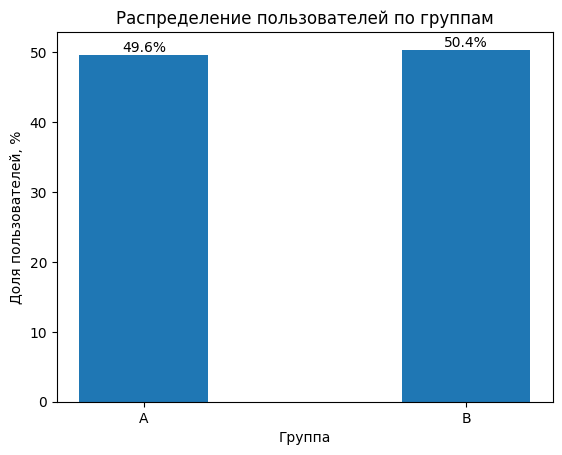

In [117]:
# Оценим равномерность распределения пользователей по группам теста
group_a = participants[participants['group'] == 'A']
group_b = participants[participants['group'] == 'B']

group_a_n = group_a.shape[0] * 100.0 / participants.shape[0]
group_b_n = group_b.shape[0] * 100.0 / participants.shape[0]

fig, ax = plt.subplots()
bars = ax.bar(['A', 'B'], 
        [group_a_n, group_b_n],
        width=0.4
        )
ax.bar_label(bars, fmt = '%.1f%%')
ax.set_title('Распределение пользователей по группам')
ax.set_xlabel('Группа')
ax.set_ylabel('Доля пользователей, %')

plt.show()

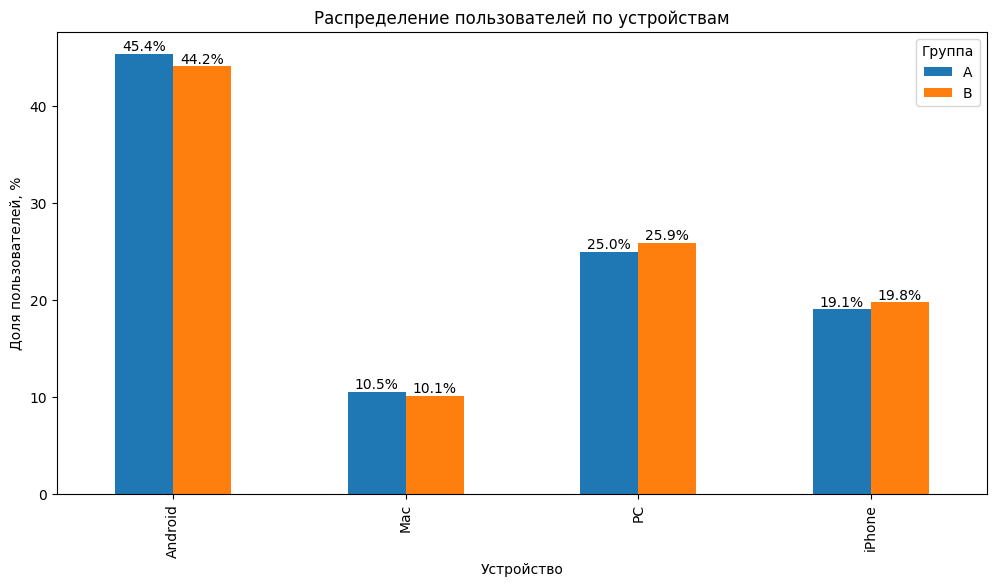

In [116]:
# Распределение устройств по группам
users_by_device = participants.groupby(['device', 'group'])['user_id'].nunique().unstack()
users_by_device = users_by_device / users_by_device.sum() * 100

ax = users_by_device.plot(kind='bar', figsize=(12, 6))

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%')

ax.set_title('Распределение пользователей по устройствам')
ax.set_xlabel('Устройство')
ax.set_ylabel('Доля пользователей, %')
ax.legend(title='Группа')
plt.show()

In [11]:
# Проверим пересечение групп
users_a = group_a['user_id']
users_b = group_b['user_id']
intersection = list(set(users_a) & set(users_b))
print(f"Количество пользователей, которые попали в обе группы = {len(intersection)}")

Количество пользователей, которые попали в обе группы = 0


**Вывод:**

Распределение пользователей по группам произошло равномерно. В обеих группах практически одинаковое количество пользователей (49.6% и 50.4%). Соотношение устройств внутри групп так же одинаково: преобладают пользователи Android (45.4% и 44.2%) и PC(25% и 25.9%). Пересечений между группами не выявлено. Соответственно, A/B тест организован верно.

## Расчёт метрики

In [12]:
# Загрузка таблицы с данными о пользовательской активности
events = pd.read_csv('ab_test_events.csv')
events.info()

C:\Users\Камила\AppData\Local\Temp\ipykernel_68764\1906499098.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv('ab_test_events.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     787286 non-null  object
 1   event_dt    787286 non-null  object
 2   event_name  787286 non-null  object
 3   details     249022 non-null  object
dtypes: object(4)
memory usage: 24.0+ MB


In [21]:
events['event_dt'] = pd.to_datetime(events['event_dt'])
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [22]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [100]:
mask = events['user_id'].isin(participants['user_id'])
test_events = events[mask]
print(f"Отобрали данные о {test_events.shape[0]} из {events.shape[0]} пользователей")

# Рассчитаем время от регистрации до каждого события пользователя
test_events = test_events.copy()
registration = (
    test_events.loc[test_events['event_name'] == 'registration']
    .groupby('user_id')['event_dt']
    .min()
    .rename('registration_dt')
)
test_events = test_events.merge(registration, on='user_id', how='inner')
test_events['lifetime'] = test_events['event_dt'] - test_events['registration_dt']
test_events['lifetime_days'] = test_events['lifetime'].dt.days

# Оставим события, произошедшие в течение первых семи суток после регистрации
test_events = test_events[
    (test_events['lifetime_days'] >= 0) &
    (test_events['lifetime_days'] < 7)
]

registration_dt = test_events.groupby('user_id')['registration_dt'].first()
last_event = test_events.groupby('user_id')['event_dt'].max()

print(f'Событий, произошедших в течение первых 7 дней после регистрации: {test_events.shape[0]}')
test_events.tail()

Отобрали данные о 79715 из 787286 пользователей
Событий, произошедших в течение первых 7 дней после регистрации: 68949


,user_id,event_dt,event_name,details,registration_dt,lifetime,lifetime_days
79551,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6 days 12:10:55,6
79554,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6 days 12:12:08,6
79628,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6 days 08:53:27,6
79634,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6 days 08:55:13,6
79692,31DBDCA380DD035F,2020-12-29 23:41:16,product_page,NaN,2020-12-23 18:11:40,6 days 05:29:36,6


In [101]:
test_events['event_name'].unique()

array(['registration', 'login', 'product_page', 'purchase',
       'product_cart'], dtype=object)

In [102]:
# Рассчитаем для каждой группы количество сделавших покупку и общее количество пользователей
users = participants[['user_id', 'group']].drop_duplicates().copy()
purchases = test_events.loc[
    test_events['event_name'] == 'purchase',
    'user_id'
].drop_duplicates()
users['conversion'] = users['user_id'].isin(purchases).astype(int)

conversion_a = users.loc[users['group'] == 'A', 'conversion']
conversion_b = users.loc[users['group'] == 'B', 'conversion']

rate_a = conversion_a.mean()
rate_b = conversion_b.mean()

print(f"Доля пользователей, совершивших покупку в течение 7 дней после регистрации, в группе A = {(rate_a * 100):.2f}%")
print(f"Доля пользователей, совершивших покупку в течение 7 дней после регистрации, в группе B = {(rate_b * 100):.2f}%")
print(f'Разница B - A: {rate_b - rate_a:.2%}')

Доля пользователей, совершивших покупку в течение 7 дней после регистрации, в группе A = 27.49%
Доля пользователей, совершивших покупку в течение 7 дней после регистрации, в группе B = 29.27%
Разница B - A: 1.77%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Вывод:**
в тестовой группе доля пользователей, которые совершили покупку в первую неделю после регистрации, оказалась на 1,77% больше, чем в контрольной группе.

## Статистическая проверка результатов A/B-теста

H0: конверсия в группах A и B одинаковая.

H1: конверсия в группе B выше, чем в группе A.

Уровень значимости: 0.05

In [107]:
from statsmodels.stats.proportion import proportions_ztest

m_a, m_b = conversion_a.sum(), conversion_b.sum()
n_a, n_b = conversion_a.shape[0], conversion_b.shape[0]

alpha = 0.05
z_stat, p_value = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

if p_value > alpha:
    print(f"p-value = {p_value:.2f} > {alpha}")
    print("Гипотеза H0 принимается. Конверсия в группах одинаковая.")
else:
    print(f"p-value = {p_value:.2f} < {alpha}")
    print("Гипотеза H0 отвергается. Конверсия в группе B больше, чем в группе A.")

p-value = 0.02 < 0.05
Гипотеза H0 отвергается. Конверсия в группе B больше, чем в группе A.


## Вывод

Конверсия в тестовой группе статистически значимо выше конверсии в контрольной группе. Однако наблюдаемый прирост составляет 1,77 процентного пункта и не достигает целевого значения 3 п.п. Поэтому статистическая значимость эффекта подтверждена, но бизнес-гипотеза о приросте минимум на 3 п.п. не подтверждена.